# Naive Bayes Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\Zeyad\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
# Load dataset
df = pd.read_csv('heart.csv')

# Quick sanity checks
df.head()     # first 5 rows


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe().transpose()  # basic stats

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [6]:
# Separate features and label
X = df.drop(columns=['target'])  # all input features
y = df['target']                 # output label

# Sanity check
print(X.shape, y.shape)
print(y.value_counts())

(303, 13) (303,)
target
1    165
0    138
Name: count, dtype: int64


**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,        
    random_state=101,      
    stratify=y            
)

print(X_train.shape, X_test.shape)

(272, 13) (31, 13)


**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage.**

In [8]:
# Create the scaler
scaler = StandardScaler()

# Fit only on the training data
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print(X_train_scaled[:5])

X_train_scaled shape: (272, 13)
X_test_scaled shape: (31, 13)
[[ 0.43296674  0.66843736  1.00125986  0.02194162 -0.40992253 -0.39679568
  -0.98127477  1.00959356 -0.67419986  1.7942432   0.96988799  1.2477898
   1.16681308]
 [-0.89274006 -1.49602648 -0.93024852  0.36625633 -0.04308623 -0.39679568
  -0.98127477  0.09524468  1.4832397  -0.89418731 -0.63870672 -0.70839939
  -0.46913103]
 [ 1.75867355  0.66843736 -0.93024852 -0.09282995  1.48218049 -0.39679568
  -0.98127477 -1.77699352 -0.67419986  1.12213557 -0.63870672  2.22588439
  -0.46913103]
 [ 0.10154004  0.66843736  0.03550567 -0.09282995  0.32375007 -0.39679568
   0.91168082  0.22586595 -0.67419986 -0.89418731  0.96988799 -0.70839939
  -0.46913103]
 [ 0.65391788  0.66843736 -0.93024852 -0.09282995  0.14998551 -0.39679568
   0.91168082 -0.25307871  1.4832397   0.28200104  0.96988799  0.2696952
   1.16681308]]


## Naive Bayes Model

**TASK: Create Naive Bayes model

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

Why Gaussian?
Because your input features are continuous numerical values, and Gaussian Naive Bayes assumes each feature follows a normal distribution within each class.

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [12]:
y_pred = nb_model.predict(X_test_scaled)


In [13]:
# 1) Confusion Matrix Array
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)

Confusion Matrix Array:
[[13  1]
 [ 5 12]]


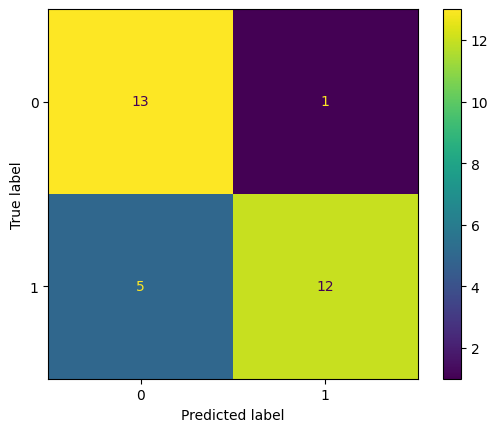

In [14]:
# 2) Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [15]:
# 3) Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81        14
           1       0.92      0.71      0.80        17

    accuracy                           0.81        31
   macro avg       0.82      0.82      0.81        31
weighted avg       0.83      0.81      0.81        31



The model performs solidly overall with 81% accuracy, and the balanced macro average suggests it handles both classes reasonably well rather than collapsing onto one class. It is better at catching class 0 with high recall (0.93), while for class 1 it is more precise than sensitive, meaning it misses some actual class 1 cases.

**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

In [16]:

# New patient data
new_patient = pd.DataFrame([{
    'age': 48.0,
    'sex': 0.0,
    'cp': 2.0,
    'trestbps': 130.0,
    'chol': 275.0,
    'fbs': 0.0,
    'restecg': 1.0,
    'thalach': 139.0,
    'exang': 0.0,
    'oldpeak': 0.2,
    'slope': 2.0,
    'ca': 0.0,
    'thal': 2.0
}])

In [17]:
# Scale using the already-fitted scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction = nb_model.predict(new_patient_scaled)
prediction_proba = nb_model.predict_proba(new_patient_scaled)

print("Predicted class:", prediction[0])
print("Prediction probabilities:", prediction_proba[0])

Predicted class: 1
Prediction probabilities: [5.90831907e-04 9.99409168e-01]


**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

The model predicts class 1, so yes, it predicts that this patient has heart disease. It is extremely confident in that prediction, with probabilities of about 99.89% for class 1 and 0.11% for class 0.